# Bubble inference: predict → review in napari → export

Applies your **finalised trained model** (from `bubble_training.ipynb`) to any selection of frames: single frames,
frame ranges, whole trains or runs, the same frame number over several trains or runs. You then correct the predictions in napari and export the reviewed bubbles for `bubble_analysis.ipynb`.

1. **Select** frames (section 2).
2. **Predict**: the model's bubbles are written as editable circles / ellipses (section 3).
3. **Review** in napari: delete false positives, add missed bubbles, fix outlines, tick **Reviewed** (section 4).
4. **Export** measurements of the reviewed frames (section 5).
5. Retrain: `bubble_training.ipynb` picks up the reviewed frames automatically.

Everything for one analysis lives in `results/<RUN_NAME>/` (it may hold frames of several runs):

| file | content |
|---|---|
| `shapes/<frame>.tif`, `shapes/<frame>.json` | frame + bubble outlines (napari circles / ellipses, overlaps allowed); the editable result |
| `bubbles.csv` | one row per bubble: centre, area, equivalent radius, ellipse axes, edge flags (px and µm) |
| `frames.csv` | one row per frame: run, train, frame number, bubble counts, reviewed flag |
| `run_info.json`, `export_settings.json` | model and settings used |

Re-running is safe: frames that already have a JSON are never overwritten (so your corrections are kept).

In [11]:
import os, time, dataclasses
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import bubble_seg as bs
import bubble_rcnn as br
import bubble_io as bio

import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
plt.rcParams["figure.dpi"] = 90

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch 2.14.1+cu130 | CUDA: True | NVIDIA A100-PCIE-40GB


## CONFIG

In [29]:
RAW_DIR = "raw"                                   # folder with the clean frames raw/jpg_<run>/ (_annotated copies are never used)
RUNS = None                                       # runs to choose frames from: None = every run in RAW_DIR, or e.g. ["r571", "r572"]
MODEL_PATH = "models/bubble_rcnn_best.pt"         # your finalised model
RESULTS_ROOT = "results"
RUN_NAME = "r574"                                 # results folder of this analysis (may hold frames of several runs)
RUN_DIR = os.path.join(RESULTS_ROOT, RUN_NAME)

# inference + measurement settings (override what is stored with the model)
INFER = dict(
    score_thresh=0.5,            # lower -> more bubbles drafted (deleting a false one is quicker than drawing a missed one)
    mask_thresh=0.5,
    mask_nms_iou=0.7,
    detections_per_img=1000,     # max bubbles per frame
    um_per_px=3.2,
    # bubbles cut by the image edge: fitted from their visible arc (centre may lie outside the image)
    edge_min_arc_deg=100.0, edge_ellipse_gain=1.6, edge_max_axis_ratio=2.5, edge_reliable_arc_deg=140.0,
    # optional exclusions: rows stay in bubbles.csv with in_analysis=False
    drop_unreliable_fits=False,
    drop_edge_bubbles=False,
    inner_margin=0.0,            # native px: exclude bubbles whose centre is closer than this to the edge
)
DRAFT_KIND = "auto"              # "auto": circle where the bubble is round, else ellipse; "ellipse" / "circle": always that
OVERWRITE_UNREVIEWED = False     # True: re-draft frames that exist but are not reviewed yet (e.g. after retraining)

## 1. Load the model

In [30]:
model, mcfg = br.load_model(MODEL_PATH)
mcfg = dataclasses.replace(mcfg, **INFER)
print(f"loaded {MODEL_PATH} on {next(model.parameters()).device}  (model_scale {mcfg.model_scale}, channels {mcfg.channels})")
bio.write_run_info(RUN_DIR, MODEL_PATH, mcfg)
index = bio.index_frames(RAW_DIR, runs=RUNS)      # {(run, train, frame): path}
bio.describe_index(index)
print(f"results -> {os.path.abspath(RUN_DIR)}")

loaded models/bubble_rcnn_best.pt on cuda:0  (model_scale 3.0, channels ('norm', 'clahe', 'ridge'))
46376 frames in 29 run(s)
  r548: trains [0, 1, 2] (744 frames)
  r549: trains [0, 1, 2] (744 frames)
  r551: trains [0, 1, 2] (744 frames)
  r552: trains [0, 1, 2, 3, 4, 5] (1488 frames)
  r553: trains [0, 1, 2] (744 frames)
  r554: trains [0, 1, 2, 3] (992 frames)
  r555: trains [0] (248 frames)
  r556: trains [0, 1, 2, 3, 4, 5, 6, 7, 8] (2232 frames)
  r557: trains [0, 1, 2, 3, 4, 5, 6, 7, 8] (2232 frames)
  r558: trains [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] (2976 frames)
  r559: trains [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] (3224 frames)
  r560: trains [0, 1, 2, 3, 4, 5, 6] (1736 frames)
  r561: trains [0, 1, 2, 3, 4, 5, 6, 7] (1984 frames)
  r562: trains [0, 1, 2, 3, 4, 5, 6, 7, 8] (2232 frames)
  r563: trains [0, 1, 2, 3, 4, 5, 6, 7] (1984 frames)
  r564: trains [0, 1, 2, 3, 4, 5, 6] (1736 frames)
  r565: trains [0, 1, 2, 3, 4, 5] (1488 frames)
  r566: trains [0, 1, 2, 3, 4, 5

## 2. Select frames

Each item is `(run, train, frames)`; any of the three can be one value, a list or `"all"`, and frames also a range.
Mix as many items as you like in `SELECTION`:

| item | meaning |
|---|---|
| `("r571", 0, 10)` or `"r571_tid0_010"` | run r571, train 0, frame 10 |
| `("r571", 0, [10, 20, 30])` | several frames of train 0 |
| `("r571", 0, "10-20")` or `("r571", 0, "10-20,30,40-45")` | ranges (end inclusive) |
| `("r571", 3, "all")` or `"r571_tid3"` | a whole train (248 frames: ~25 min on an A100, and you will only review some) |
| `("r571", "all", 10)` | frame 10 of every train of r571 |
| `(["r571", "r572"], "all", 10)` or `("all", "all", 10)` | frame 10 of every train of several / all runs in `RUNS` |
| `"r571"` | a whole run |
| `(0, 10)` or `"tid0_010"` | train 0, frame 10 of every run in `RUNS` |

Runs not in `RUNS` (CONFIG) are not indexed, so they cannot be selected.

The preview uses a fixed grey scale, so over- or under-exposed frames are easy to spot.

7 frames selected
  r574: train 0: 1, train 1: 1, train 2: 1, train 3: 1, train 4: 1, train 5: 1, train 6: 1


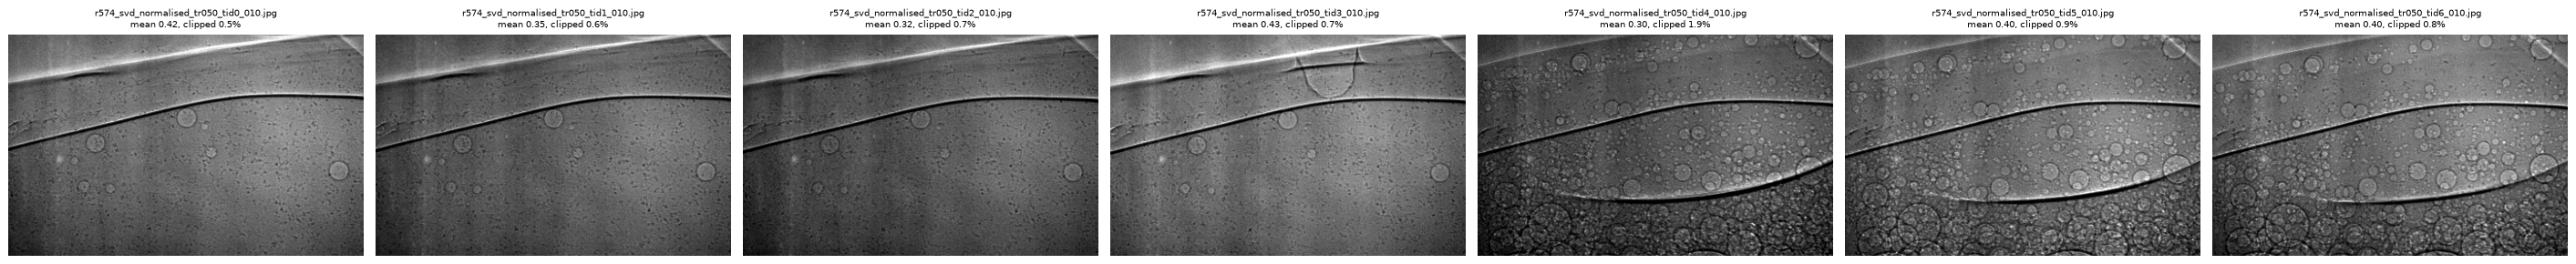

In [31]:
SELECTION = [
    ("r574", "all", 10),         # e.g. frame 10 of every train of r571; edit freely (see the table above)
]
PREVIEW = True

paths = bio.select_frames(SELECTION, index)
if PREVIEW:
    bio.preview_frames(paths)

## 3. Predict and write drafts

Each selected frame gets `shapes/<frame>.tif` + `shapes/<frame>.json` with the model's bubbles as circles / ellipses.
Frames that already exist are skipped (your edits are safe), unless `OVERWRITE_UNREVIEWED = True` and the frame is
neither reviewed nor corrected yet. A frame you already reviewed in another results folder is copied from there
(still reviewed) instead of being predicted again.

In [32]:
RUN_DRAFT = True
if RUN_DRAFT:
    t = time.time()
    bio.write_run_info(RUN_DIR, MODEL_PATH, mcfg, selection=SELECTION)
    summary = bio.draft_frames(model, mcfg, paths, RUN_DIR, model_path=MODEL_PATH, kind=DRAFT_KIND,
                               overwrite_unreviewed=OVERWRITE_UNREVIEWED, show_every=10)
    print(f"done in {time.time() - t:.0f}s")
    display(summary["status"].value_counts().to_frame())

1/7  r574_svd_normalised_tr050_tid0_010: 15 bubbles  (2s)
7/7  r574_svd_normalised_tr050_tid6_010: 590 bubbles  (22s)
done in 23s


,count
status,
drafted,7


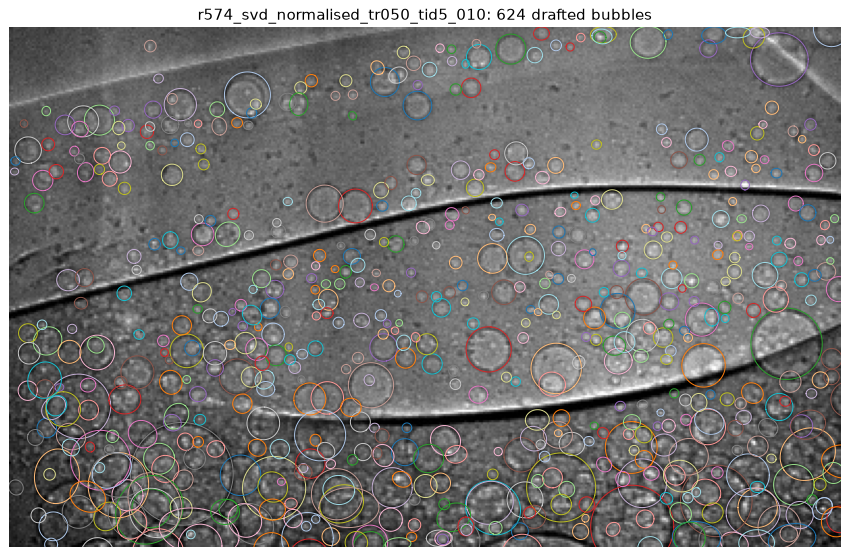

In [33]:
# look at one drafted frame
status = bio.list_results(RUN_DIR)
if len(status):
    show = status.iloc[min(5, len(status) - 1)]["frame"]
    img, shapes = bio.load_frame(RUN_DIR, show)
    bio.plot_shapes(img, shapes, title=f"{show}: {len(shapes)} drafted bubbles");

## 4. Review in napari (FastX desktop terminal)

```bash
cd /path/to/foam_analysis
python annotate_bubbles.py results/<RUN_NAME>/shapes     # lists frames, Enter = first frame not yet reviewed
```
* **False positive:** select tool (**S**), click the shape, **Delete**.
* **Missed bubble:** **E** ellipse (select it and press **C** to make it a circle), full outline including hidden
  parts. A circle / ellipse may extend beyond the image edge; its centre and size are then used exactly.
* **Wrong outline:** select and drag the handles to move / resize / rotate, or delete and redraw.
* Ignore the *fully annotated* layer here (it is only used for training). Tick **Reviewed** only for frames you
  checked completely: reviewed frames are exported whole for the analysis and added to the training set.
* When the frame is fully checked, tick **Reviewed**. It saves immediately. Then close the window and open the next frame.
  (The file is only rewritten when something changed, so just looking at a frame changes nothing.)

Re-run the cell below to see the status.

In [34]:
status = bio.list_results(RUN_DIR)
print(f"{status['reviewed'].sum()} of {len(status)} frames reviewed")
print(f"python annotate_bubbles.py {os.path.join(RUN_DIR, 'shapes')}")
display(status.drop(columns=["json_path"]))

0 of 7 frames reviewed
python annotate_bubbles.py results/r574/shapes


,frame,run,train,frame_idx,n_bubbles,reviewed,model
0,r574_svd_normalised_tr050_tid0_010,r574,0,10,15,False,bubble_rcnn_best.pt
1,r574_svd_normalised_tr050_tid1_010,r574,1,10,19,False,bubble_rcnn_best.pt
2,r574_svd_normalised_tr050_tid2_010,r574,2,10,24,False,bubble_rcnn_best.pt
3,r574_svd_normalised_tr050_tid3_010,r574,3,10,25,False,bubble_rcnn_best.pt
4,r574_svd_normalised_tr050_tid4_010,r574,4,10,584,False,bubble_rcnn_best.pt
5,r574_svd_normalised_tr050_tid5_010,r574,5,10,624,False,bubble_rcnn_best.pt
6,r574_svd_normalised_tr050_tid6_010,r574,6,10,590,False,bubble_rcnn_best.pt


## 5. Export measurements

Measures every reviewed frame and writes `bubbles.csv` and `frames.csv` (with a `run` column, so frames of several
runs can be told apart). Each bubble's circle / ellipse is measured exactly; bubbles cut by the image edge keep their
full fitted size, with `edge_truncated`, `arc_deg` and `fit_reliable` describing how much of them is visible.
Re-run after any further corrections.

In [35]:
INCLUDE_UNREVIEWED = True       # True: also export frames you have not ticked as reviewed (flagged reviewed=False)

bubbles, frames_tbl = bio.export_results(RUN_DIR, mcfg, include_unreviewed=INCLUDE_UNREVIEWED)
display(frames_tbl)
display(bubbles.round(2).head(10))

exported 7 frames, 1881 bubbles -> results/r574/bubbles.csv, frames.csv


,frame,run,train,frame_idx,reviewed,n_bubbles,n_in_analysis,image_height_px,image_width_px,model,shapes_key
0,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,15,15,250,400,bubble_rcnn_best.pt,f6127c69481519ca
1,r574_svd_normalised_tr050_tid1_010,r574,1,10,False,19,19,250,400,bubble_rcnn_best.pt,3bc63cd93d980f16
2,r574_svd_normalised_tr050_tid2_010,r574,2,10,False,24,24,250,400,bubble_rcnn_best.pt,a467109394daa64e
3,r574_svd_normalised_tr050_tid3_010,r574,3,10,False,25,25,250,400,bubble_rcnn_best.pt,88defb4fff597d18
4,r574_svd_normalised_tr050_tid4_010,r574,4,10,False,584,584,250,400,bubble_rcnn_best.pt,4b8cab557e566f95
5,r574_svd_normalised_tr050_tid5_010,r574,5,10,False,624,624,250,400,bubble_rcnn_best.pt,ed1b757b1cc0f277
6,r574_svd_normalised_tr050_tid6_010,r574,6,10,False,590,590,250,400,bubble_rcnn_best.pt,7e709fb6d2f49bdc


,frame,run,train,frame_idx,reviewed,bubble_id,shape_type,x,y,area_px2,...,fit_kind,arc_deg,outline_visible_frac,fit_reliable,in_analysis,r_eq_um,area_um2,area_visible_um2,major_axis_um,minor_axis_um
0,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,0,circle,371.89,153.42,406.11,...,circle,360.0,1.0,True,True,36.38,4158.58,4161.99,72.77,72.77
1,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,1,circle,97.87,121.84,394.22,...,circle,360.0,1.0,True,True,35.85,4036.84,4036.84,71.69,71.69
2,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,2,circle,200.34,93.52,409.78,...,circle,360.0,1.0,True,True,36.55,4196.15,4188.16,73.09,73.09
3,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,3,circle,114.23,173.37,92.67,...,circle,360.0,1.0,True,True,17.38,948.92,946.63,34.76,34.76
4,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,4,circle,220.60,103.57,66.89,...,circle,360.0,1.0,True,True,14.77,684.94,684.94,29.53,29.53
5,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,5,circle,73.92,141.83,70.11,...,circle,360.0,1.0,True,True,15.12,717.94,716.80,30.23,30.23
6,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,6,ellipse,57.49,140.45,87.67,...,ellipse,360.0,1.0,True,True,16.90,897.71,896.57,35.30,32.38
7,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,7,circle,84.34,171.15,143.33,...,circle,360.0,1.0,True,True,21.61,1467.68,1468.87,43.23,43.23
8,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,8,circle,228.32,132.62,123.62,...,circle,360.0,1.0,True,True,20.07,1265.87,1260.66,40.15,40.15
9,r574_svd_normalised_tr050_tid0_010,r574,0,10,False,9,circle,147.25,114.45,20.22,...,circle,360.0,1.0,True,True,8.12,207.08,203.66,16.24,16.24


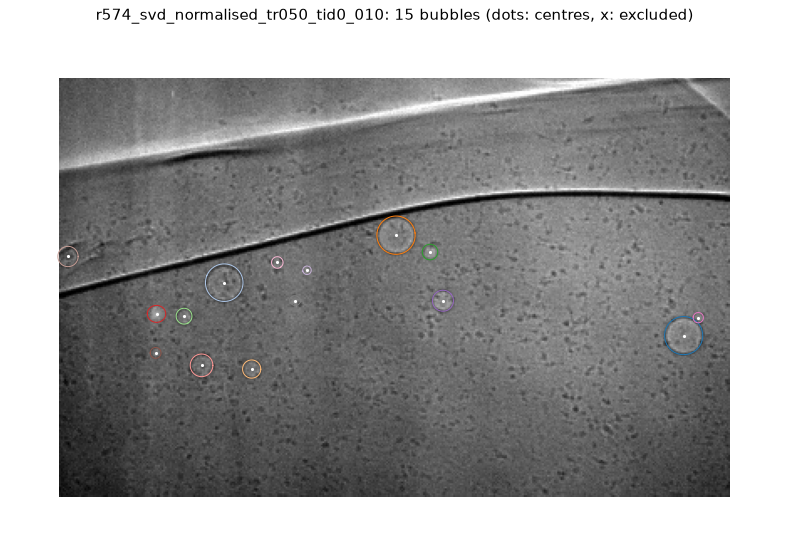

In [36]:
# check one exported frame: outlines + measured centres (edge bubbles: centre may be outside the image)
if len(frames_tbl):
    show = frames_tbl.iloc[0]["frame"]
    img, shapes = bio.load_frame(RUN_DIR, show)
    b = bubbles[bubbles["frame"] == show]
    ax = bio.plot_shapes(img, shapes, title=f"{show}: {len(b)} bubbles (dots: centres, x: excluded)", view_pad=30)
    ax.plot(b.loc[b["in_analysis"], "x"], b.loc[b["in_analysis"], "y"], ".", ms=3, color="w")
    ax.plot(b.loc[~b["in_analysis"], "x"], b.loc[~b["in_analysis"], "y"], "x", ms=4, color="0.6")

## 6. *(optional)* Add reviewed frames to the training set now

`bubble_training.ipynb` copies all reviewed frames from `results/` automatically (section 4), so you normally don't
need this. It does the same for this run only: new reviewed frames are copied (whole frame = fully annotated), and
frames you corrected again are updated. Annotations made in `annotations/` itself are never overwritten.

In [10]:
COPY_TO_TRAINING = False
if COPY_TO_TRAINING:
    bio.copy_to_training(RUN_DIR, "annotations")